In [93]:
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [94]:
X,y=load_diabetes(return_X_y=True)
print(f"X: {X}")
print("\n\n")
print(f"Y: {y}")

X: [[ 0.03807591  0.05068012  0.06169621 ... -0.00259226  0.01990749
  -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 ... -0.03949338 -0.06833155
  -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 ... -0.00259226  0.00286131
  -0.02593034]
 ...
 [ 0.04170844  0.05068012 -0.01590626 ... -0.01107952 -0.04688253
   0.01549073]
 [-0.04547248 -0.04464164  0.03906215 ...  0.02655962  0.04452873
  -0.02593034]
 [-0.04547248 -0.04464164 -0.0730303  ... -0.03949338 -0.00422151
   0.00306441]]



Y: [151.  75. 141. 206. 135.  97. 138.  63. 110. 310. 101.  69. 179. 185.
 118. 171. 166. 144.  97. 168.  68.  49.  68. 245. 184. 202. 137.  85.
 131. 283. 129.  59. 341.  87.  65. 102. 265. 276. 252.  90. 100.  55.
  61.  92. 259.  53. 190. 142.  75. 142. 155. 225.  59. 104. 182. 128.
  52.  37. 170. 170.  61. 144.  52. 128.  71. 163. 150.  97. 160. 178.
  48. 270. 202. 111.  85.  42. 170. 200. 252. 113. 143.  51.  52. 210.
  65. 141.  55. 134.  42. 111.  98. 164.  48.  96.  90. 162. 150. 279.
  

In [95]:
X.shape

(442, 10)

In [96]:
y.shape

(442,)

In [97]:
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [98]:
reg=LinearRegression()
reg.fit(X_train,Y_train)

LinearRegression()

In [99]:
Y_pred=reg.predict(X_test)
Y_pred

array([154.1213881 , 204.81835118, 124.93755353, 106.08950893,
       258.5348576 , 256.3310074 , 118.75087616, 119.52440696,
       101.50816735, 190.54048661, 141.70656811, 172.51883961,
       174.33861649, 134.80942706, 294.13994537,  94.11798038,
       211.97059795, 156.49579378, 134.21000428, 119.62664644,
       148.87842251, 165.00873409, 151.10021038, 176.04063756,
       133.27769647, 221.29555392, 197.17324941,  96.1577688 ,
        50.26012711, 230.48580317, 242.06073866, 114.11129218,
        67.07532417,  94.52943825, 201.21415375, 167.05136201,
       159.881268  , 192.78746659, 114.49551325, 233.48234551,
       140.82563045, 121.0680409 , 192.27480772, 191.12738845,
       179.16865788, 148.34935601, 163.47414622, 276.81647884,
       100.17926432, 164.10555298, 255.80762189, 136.9466204 ,
       152.37503699, 107.92237882, 194.21924678,  77.34670792,
       118.50482479,  68.38335763, 154.29258529, 162.48840259,
       168.36788326, 156.87790322,  97.14191797, 238.16

In [100]:
reg.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [101]:
reg.intercept_

np.float64(151.88331005254167)

In [102]:
r2_score(Y_test,Y_pred)

0.4399338661568968

In [103]:
import random
class MIBGRegressor:
  def __init__(self,Batch_size=10,learning_rate=0.01,epoches=100):
    self.coef_=None
    self.intercept_=None
    self.learning_rate=learning_rate
    self.Batch_size=Batch_size
    self.epoches=epoches

  def fit(self,X_train,Y_train):
    self.intercept_=0
    self.coef_=np.ones(X_train.shape[1])

    for i in range(self.epoches):
      for j in range(int(X_train.shape[0]/self.Batch_size)):
         idx=random.sample(range(X_train.shape[0]),self.Batch_size)

         Y_hat=np.dot(X_train[idx],self.coef_)+self.intercept_

         intercept_derivative=-2*np.mean(Y_train[idx]-Y_hat)

         self.intercept_=self.intercept_-(self.learning_rate * intercept_derivative)

         coefficient_derivative=-2 * np.dot((Y_train[idx]-Y_hat),X_train[idx])

         self.coef_=self.coef_ - (self.learning_rate * coefficient_derivative)
    print(f"""Intercept is : {self.intercept_} \n coefficient is : {self.coef_}""")

  def Predict(self,X_test):
    return np.dot(X_test,self.coef_)+self.intercept_

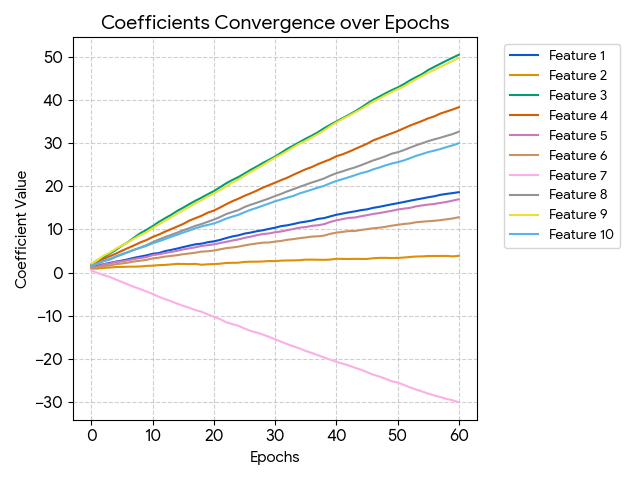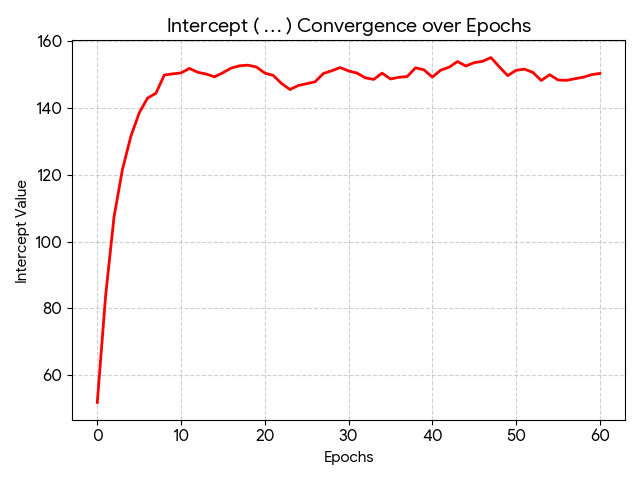

In [104]:
MIBGR=MIBGRegressor(Batch_size=int(X_train.shape[0]/20),learning_rate=0.01,epoches=61)
MIBGR.fit(X_train,Y_train)

Intercept is : 154.14466051808932 
 coefficient is : [  44.62309929  -80.09290845  374.5661541   269.37608598    8.27055124
  -44.39785831 -183.87017228  132.67075281  346.85467295  123.81957968]


In [105]:
Y_pred=MIBGR.Predict(X_test)
Y_pred

array([154.62091068, 195.50963373, 139.92842299, 109.35745347,
       251.83076224, 243.13048839, 109.45092625, 116.45378493,
        93.88659804, 188.59831966, 159.93691105, 176.11040308,
       186.88902942, 149.61804522, 263.34451866,  91.56664902,
       191.13652083, 143.35001296, 141.05471893, 139.73489193,
       136.03542923, 189.46414342, 167.81129404, 180.01693643,
       127.75470968, 223.3875861 , 198.59611474, 118.60063431,
        62.20671582, 244.66885456, 240.94365372, 120.10333321,
        75.14152485, 110.07474346, 203.86144348, 168.28326432,
       168.46522833, 198.76769175, 116.15385103, 237.24055754,
       138.8677711 , 127.95396488, 189.15814269, 190.40426394,
       173.5424646 , 148.86437258, 175.41816363, 286.54865042,
       118.12241071, 188.75062314, 242.86503763, 133.91752748,
       147.25719677, 148.27291304, 192.6205808 , 112.74049875,
       154.48456908,  85.32843093, 160.64101097, 147.78514561,
       166.6702338 , 172.17862599, 110.09839458, 211.75

In [106]:
Y_pred.shape

(89,)

In [107]:
r2_score(Y_test,Y_pred)

0.4396556936869922